<a href="https://colab.research.google.com/github/felipesbr11/felipe/blob/master/VinhoTinto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd



url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"



df = pd.read_csv(url, sep=';')



df['classificacao'] = pd.cut(

    df['quality'],

    bins=[0, 5, 10],

    labels=['Qualidade baixa', 'Qualidade alta']

)



print(df.head())



   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality    classificacao  
0      9.4        5  Qualidade baixa  
1      9

DATASET CARREGADO
Quantidade de linhas: 1599
Quantidade de colunas: 12

Primeiras 5 linhas:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.5

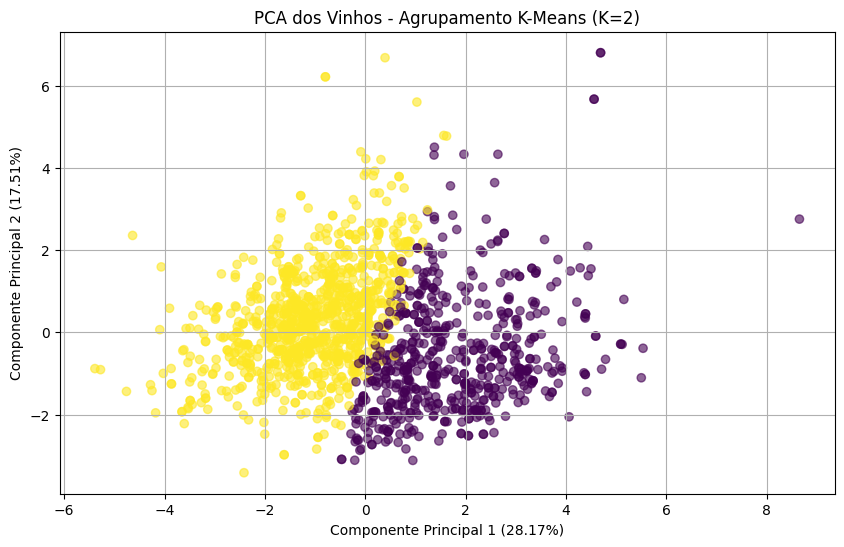

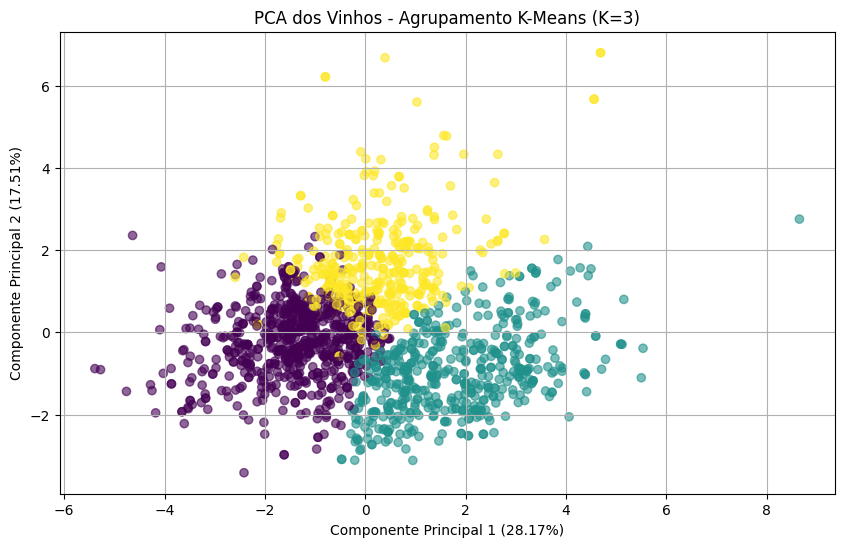

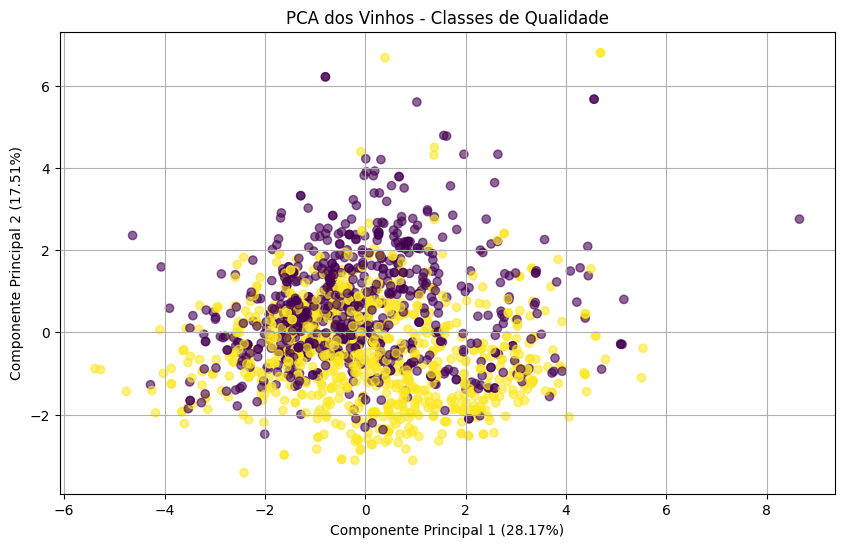



RESUMO FINAL DO PROJETO

--- CLASSIFICAÇÃO ---
           Modelo  Acurácia  Precisão  Recall  F1-score
              KNN    0.7812    0.7730  0.8363    0.8034
Árvore de Decisão    0.7406    0.7619  0.7485    0.7552

Melhor modelo pelo F1-score:
KNN

--- K-MEANS ---
 K  Silhouette Score
 2            0.2137
 3            0.1892

--- PCA ---
Variância explicada pelas 2 componentes: 45.68%

Projeto concluído com sucesso!


In [5]:
# ============================================================
# PROJETO MACHINE LEARNING - WINE QUALITY (RED)
# Dataset: UCI Wine Quality - Red Wine
# ============================================================

# ------------------------------------------------------------
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# ------------------------------------------------------------
# 2. CARREGAR O DATASET
# ------------------------------------------------------------

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=';')

print("=" * 70)
print("DATASET CARREGADO")
print("=" * 70)

print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

print("\nPrimeiras 5 linhas:")
print(df.head())


# ------------------------------------------------------------
# 3. CRIAR A NOVA VARIÁVEL DE CLASSIFICAÇÃO
# ------------------------------------------------------------

# Regra:
# quality < 6  -> Qualidade baixa
# quality >= 6 -> Qualidade alta

df['classificacao'] = df['quality'].apply(
    lambda x: 'Qualidade baixa' if x < 6 else 'Qualidade alta'
)

print("\n" + "=" * 70)
print("DISTRIBUIÇÃO DAS CLASSES")
print("=" * 70)

print(df['classificacao'].value_counts())


# ------------------------------------------------------------
# 4. SEPARAR AS VARIÁVEIS PARA CLASSIFICAÇÃO
# ------------------------------------------------------------

# X = características físico-químicas
# Não utilizamos quality nem classificacao como entrada.

X = df.drop(columns=['quality', 'classificacao'])

# y = classe que queremos prever
y = df['classificacao']


# ------------------------------------------------------------
# 5. DIVISÃO DOS DADOS EM TREINAMENTO E TESTE
# ------------------------------------------------------------

# 80% treinamento
# 20% teste

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("DIVISÃO DOS DADOS")
print("=" * 70)

print("Dados para treinamento:", X_treino.shape[0])
print("Dados para teste:", X_teste.shape[0])

print("\nPercentual de treinamento: 80%")
print("Percentual de teste: 20%")


# ============================================================
# 6. MODELO 1 - KNN
# ============================================================

# O StandardScaler é importante para o KNN porque
# o algoritmo utiliza distância entre os dados.

modelo_knn = Pipeline([
    ('padronizacao', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Treinar
modelo_knn.fit(X_treino, y_treino)

# Fazer previsões
previsoes_knn = modelo_knn.predict(X_teste)


# ============================================================
# 7. MODELO 2 - ÁRVORE DE DECISÃO
# ============================================================

modelo_arvore = DecisionTreeClassifier(
    random_state=42
)

# Treinar
modelo_arvore.fit(X_treino, y_treino)

# Fazer previsões
previsoes_arvore = modelo_arvore.predict(X_teste)


# ============================================================
# 8. FUNÇÃO PARA CALCULAR AS MÉTRICAS
# ============================================================

def calcular_metricas(y_real, y_pred):
    return {
        'Acurácia': accuracy_score(y_real, y_pred),
        'Precisão': precision_score(
            y_real,
            y_pred,
            pos_label='Qualidade alta'
        ),
        'Recall': recall_score(
            y_real,
            y_pred,
            pos_label='Qualidade alta'
        ),
        'F1-score': f1_score(
            y_real,
            y_pred,
            pos_label='Qualidade alta'
        )
    }


# Calcular métricas
metricas_knn = calcular_metricas(
    y_teste,
    previsoes_knn
)

metricas_arvore = calcular_metricas(
    y_teste,
    previsoes_arvore
)


# ============================================================
# 9. COMPARAÇÃO DOS MODELOS
# ============================================================

resultados = pd.DataFrame({
    'Modelo': [
        'KNN',
        'Árvore de Decisão'
    ],
    'Acurácia': [
        metricas_knn['Acurácia'],
        metricas_arvore['Acurácia']
    ],
    'Precisão': [
        metricas_knn['Precisão'],
        metricas_arvore['Precisão']
    ],
    'Recall': [
        metricas_knn['Recall'],
        metricas_arvore['Recall']
    ],
    'F1-score': [
        metricas_knn['F1-score'],
        metricas_arvore['F1-score']
    ]
})

print("\n" + "=" * 70)
print("COMPARAÇÃO DOS MODELOS")
print("=" * 70)

print(resultados.round(4).to_string(index=False))


# ============================================================
# 10. MATRIZ DE CONFUSÃO - KNN
# ============================================================

matriz_knn = confusion_matrix(
    y_teste,
    previsoes_knn,
    labels=['Qualidade baixa', 'Qualidade alta']
)

print("\n" + "=" * 70)
print("MATRIZ DE CONFUSÃO - KNN")
print("=" * 70)

matriz_knn_df = pd.DataFrame(
    matriz_knn,
    index=[
        'Real: Qualidade baixa',
        'Real: Qualidade alta'
    ],
    columns=[
        'Predito: Qualidade baixa',
        'Predito: Qualidade alta'
    ]
)

print(matriz_knn_df)


# ============================================================
# 11. MATRIZ DE CONFUSÃO - ÁRVORE DE DECISÃO
# ============================================================

matriz_arvore = confusion_matrix(
    y_teste,
    previsoes_arvore,
    labels=['Qualidade baixa', 'Qualidade alta']
)

print("\n" + "=" * 70)
print("MATRIZ DE CONFUSÃO - ÁRVORE DE DECISÃO")
print("=" * 70)

matriz_arvore_df = pd.DataFrame(
    matriz_arvore,
    index=[
        'Real: Qualidade baixa',
        'Real: Qualidade alta'
    ],
    columns=[
        'Predito: Qualidade baixa',
        'Predito: Qualidade alta'
    ]
)

print(matriz_arvore_df)


# ============================================================
# 12. RELATÓRIO DETALHADO
# ============================================================

print("\n" + "=" * 70)
print("RELATÓRIO DE CLASSIFICAÇÃO - KNN")
print("=" * 70)

print(
    classification_report(
        y_teste,
        previsoes_knn
    )
)


print("\n" + "=" * 70)
print("RELATÓRIO DE CLASSIFICAÇÃO - ÁRVORE DE DECISÃO")
print("=" * 70)

print(
    classification_report(
        y_teste,
        previsoes_arvore
    )
)


# ============================================================
# 13. IDENTIFICAR O MELHOR MODELO
# ============================================================

# Utilizamos o F1-score como principal referência,
# pois ele considera simultaneamente precisão e recall.

if metricas_knn['F1-score'] > metricas_arvore['F1-score']:
    melhor_modelo = "KNN"
elif metricas_arvore['F1-score'] > metricas_knn['F1-score']:
    melhor_modelo = "Árvore de Decisão"
else:
    melhor_modelo = "Empate entre os modelos"

print("\n" + "=" * 70)
print("MELHOR MODELO")
print("=" * 70)

print("Modelo com melhor F1-score:", melhor_modelo)


# ============================================================
# 14. K-MEANS - PREPARAÇÃO DOS DADOS
# ============================================================

# Para o agrupamento NÃO utilizaremos:
# quality
# classificacao

X_cluster = df.drop(
    columns=['quality', 'classificacao']
)

# Padronização
scaler_cluster = StandardScaler()

X_cluster_padronizado = scaler_cluster.fit_transform(
    X_cluster
)


# ============================================================
# 15. K-MEANS COM K = 2
# ============================================================

kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

grupos_k2 = kmeans_2.fit_predict(
    X_cluster_padronizado
)

df['grupo_k2'] = grupos_k2

silhouette_k2 = silhouette_score(
    X_cluster_padronizado,
    grupos_k2
)

print("\n" + "=" * 70)
print("K-MEANS - K = 2")
print("=" * 70)

print("Quantidade de amostras em cada grupo:")
print(
    df['grupo_k2']
    .value_counts()
    .sort_index()
)

print(
    "\nSilhouette Score:",
    round(silhouette_k2, 4)
)


# ============================================================
# 16. K-MEANS COM K = 3
# ============================================================

kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

grupos_k3 = kmeans_3.fit_predict(
    X_cluster_padronizado
)

df['grupo_k3'] = grupos_k3

silhouette_k3 = silhouette_score(
    X_cluster_padronizado,
    grupos_k3
)

print("\n" + "=" * 70)
print("K-MEANS - K = 3")
print("=" * 70)

print("Quantidade de amostras em cada grupo:")
print(
    df['grupo_k3']
    .value_counts()
    .sort_index()
)

print(
    "\nSilhouette Score:",
    round(silhouette_k3, 4)
)


# ============================================================
# 17. COMPARAÇÃO DOS AGRUPAMENTOS
# ============================================================

comparacao_kmeans = pd.DataFrame({
    'K': [2, 3],
    'Silhouette Score': [
        silhouette_k2,
        silhouette_k3
    ]
})

print("\n" + "=" * 70)
print("COMPARAÇÃO K-MEANS")
print("=" * 70)

print(
    comparacao_kmeans.round(4).to_string(index=False)
)


# ============================================================
# 18. MÉDIAS DAS CARACTERÍSTICAS - K = 2
# ============================================================

print("\n" + "=" * 70)
print("MÉDIAS DAS CARACTERÍSTICAS - K = 2")
print("=" * 70)

print(
    df.groupby('grupo_k2')[X_cluster.columns]
    .mean()
    .round(2)
)


# ============================================================
# 19. MÉDIAS DAS CARACTERÍSTICAS - K = 3
# ============================================================

print("\n" + "=" * 70)
print("MÉDIAS DAS CARACTERÍSTICAS - K = 3")
print("=" * 70)

print(
    df.groupby('grupo_k3')[X_cluster.columns]
    .mean()
    .round(2)
)


# ============================================================
# 20. PCA
# ============================================================

# O PCA será aplicado às características físico-químicas
# padronizadas.

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_cluster_padronizado
)


# Criar DataFrame para visualização
df_pca = pd.DataFrame({
    'Componente 1': X_pca[:, 0],
    'Componente 2': X_pca[:, 1],
    'Grupo K=2': grupos_k2,
    'Grupo K=3': grupos_k3,
    'Qualidade': df['classificacao']
})


# ============================================================
# 21. VARIÂNCIA EXPLICADA PELO PCA
# ============================================================

variancia_cp1 = (
    pca.explained_variance_ratio_[0] * 100
)

variancia_cp2 = (
    pca.explained_variance_ratio_[1] * 100
)

variancia_total = (
    sum(pca.explained_variance_ratio_) * 100
)

print("\n" + "=" * 70)
print("PCA - VARIÂNCIA EXPLICADA")
print("=" * 70)

print(
    f"Componente Principal 1: {variancia_cp1:.2f}%"
)

print(
    f"Componente Principal 2: {variancia_cp2:.2f}%"
)

print(
    f"Variância explicada acumulada: {variancia_total:.2f}%"
)


# ============================================================
# 22. GRÁFICO PCA - K = 2
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df_pca['Componente 1'],
    df_pca['Componente 2'],
    c=df_pca['Grupo K=2'],
    alpha=0.6
)

plt.xlabel(
    f'Componente Principal 1 ({variancia_cp1:.2f}%)'
)

plt.ylabel(
    f'Componente Principal 2 ({variancia_cp2:.2f}%)'
)

plt.title(
    'PCA dos Vinhos - Agrupamento K-Means (K=2)'
)

plt.grid(True)

plt.show()


# ============================================================
# 23. GRÁFICO PCA - K = 3
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df_pca['Componente 1'],
    df_pca['Componente 2'],
    c=df_pca['Grupo K=3'],
    alpha=0.6
)

plt.xlabel(
    f'Componente Principal 1 ({variancia_cp1:.2f}%)'
)

plt.ylabel(
    f'Componente Principal 2 ({variancia_cp2:.2f}%)'
)

plt.title(
    'PCA dos Vinhos - Agrupamento K-Means (K=3)'
)

plt.grid(True)

plt.show()


# ============================================================
# 24. GRÁFICO PCA - CLASSES DE QUALIDADE
# ============================================================

# Aqui fazemos uma visualização adicional usando
# as classes criadas anteriormente.

classes_numericas = (
    df['classificacao']
    .map({
        'Qualidade baixa': 0,
        'Qualidade alta': 1
    })
)

plt.figure(figsize=(10, 6))

plt.scatter(
    df_pca['Componente 1'],
    df_pca['Componente 2'],
    c=classes_numericas,
    alpha=0.6
)

plt.xlabel(
    f'Componente Principal 1 ({variancia_cp1:.2f}%)'
)

plt.ylabel(
    f'Componente Principal 2 ({variancia_cp2:.2f}%)'
)

plt.title(
    'PCA dos Vinhos - Classes de Qualidade'
)

plt.grid(True)

plt.show()


# ============================================================
# 25. RESUMO FINAL DOS RESULTADOS
# ============================================================

print("\n")
print("=" * 70)
print("RESUMO FINAL DO PROJETO")
print("=" * 70)

print("\n--- CLASSIFICAÇÃO ---")

print(
    resultados.round(4).to_string(index=False)
)

print("\nMelhor modelo pelo F1-score:")
print(melhor_modelo)

print("\n--- K-MEANS ---")

print(
    comparacao_kmeans.round(4).to_string(index=False)
)

print("\n--- PCA ---")

print(
    f"Variância explicada pelas 2 componentes: "
    f"{variancia_total:.2f}%"
)

print("\nProjeto concluído com sucesso!")